![Brats official annotations](https://www.med.upenn.edu/cbica/assets/user-content/images/BraTS/brats-tumor-subregions.jpg)

In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

patient_path = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"

modalities = {
    "T1":"BraTS20_Training_001_t1.nii",
    "T1CE":"BraTS20_Training_001_t1ce.nii",
    "T2":"BraTS20_Training_001_t2.nii",
    "FLAIR":"BraTS20_Training_001_flair.nii",
    "SEG":"BraTS20_Training_001_seg.nii"
}

images = {}

for key,file in modalities.items():
    img = nib.load(os.path.join(patient_path,file))
    images[key] = img.get_fdata()

print(images["T1"].shape)

(240, 240, 155)


# Display Middle Slice of Every Modality

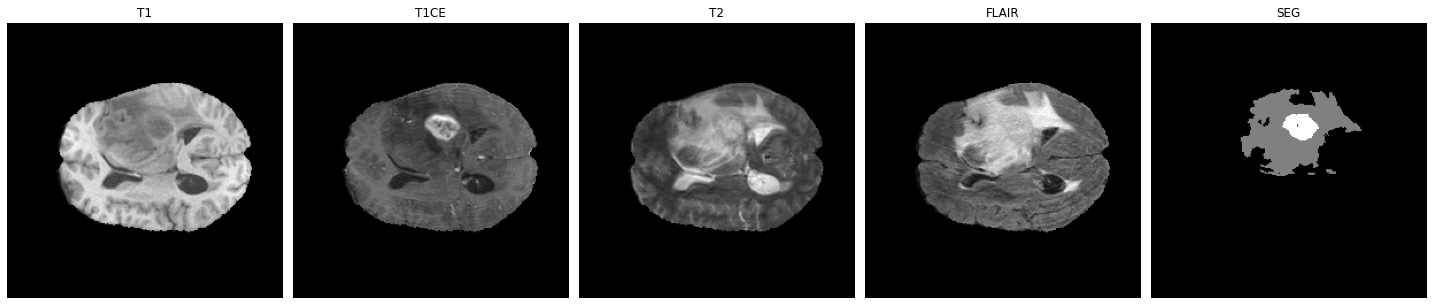

In [2]:
slice_no = images["T1"].shape[2]//2

fig,ax = plt.subplots(1,5,figsize=(20,5))

for i,key in enumerate(images.keys()):
    ax[i].imshow(images[key][:,:,slice_no], cmap='gray')
    ax[i].set_title(key)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

# Multiple Slice Visualization

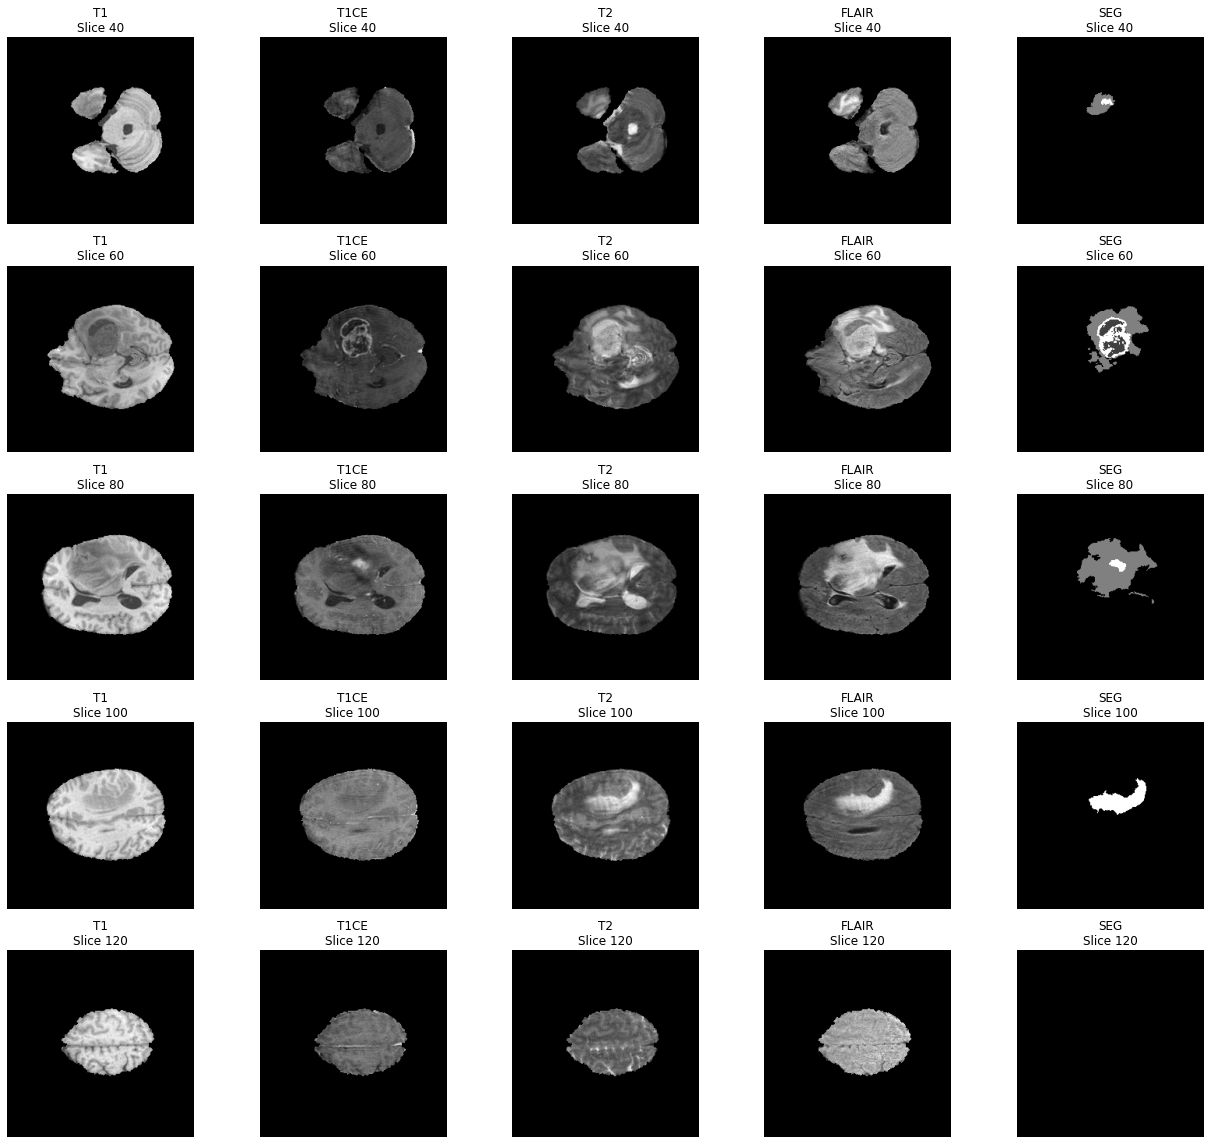

In [3]:
slice_numbers = [40,60,80,100,120]

fig,axes = plt.subplots(len(slice_numbers),5,figsize=(18,16))

mods=list(images.keys())

for i,s in enumerate(slice_numbers):

    for j,m in enumerate(mods):

        axes[i,j].imshow(images[m][:,:,s],cmap='gray')
        axes[i,j].set_title(f"{m}\nSlice {s}")
        axes[i,j].axis("off")

plt.tight_layout()
plt.show()

# Overlay Tumor Mask on MRI

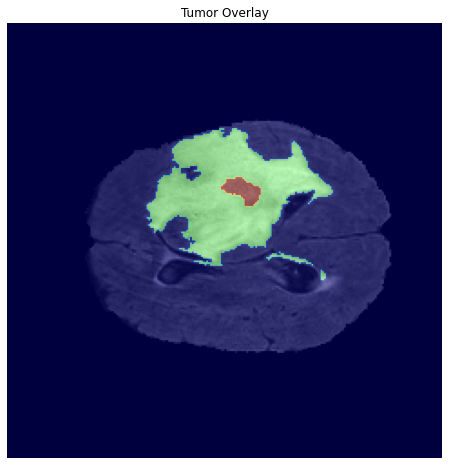

In [4]:
slice_no=80

plt.figure(figsize=(8,8))

plt.imshow(images["FLAIR"][:,:,slice_no],cmap='gray')

plt.imshow(images["SEG"][:,:,slice_no],
           cmap='jet',
           alpha=0.5)

plt.title("Tumor Overlay")
plt.axis("off")
plt.show()

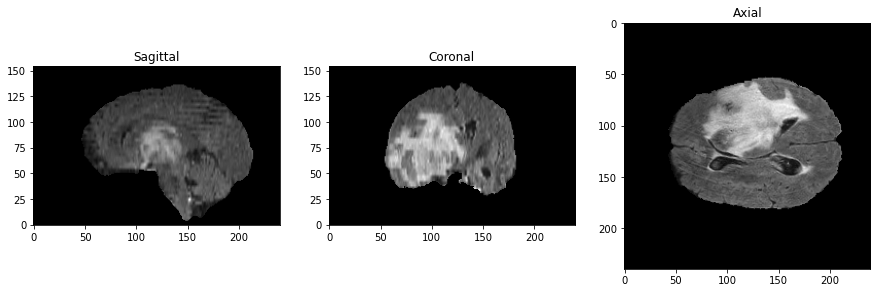

In [5]:
x=120
y=120
z=80

fig,ax=plt.subplots(1,3,figsize=(15,5))

ax[0].imshow(images["FLAIR"][x,:,:].T,
             cmap='gray',
             origin='lower')
ax[0].set_title("Sagittal")

ax[1].imshow(images["FLAIR"][:,y,:].T,
             cmap='gray',
             origin='lower')
ax[1].set_title("Coronal")

ax[2].imshow(images["FLAIR"][:,:,z],
             cmap='gray')
ax[2].set_title("Axial")

plt.show()

In [6]:

seg_path = os.path.join(patient_path, modalities["SEG"])

seg_img = nib.load(seg_path)
seg = seg_img.get_fdata()   

voxel_size = seg_img.header.get_zooms()[:3]  
voxel_volume = np.prod(voxel_size)          

tumor_volume = np.sum(seg > 0) * voxel_volume

print(f"Voxel Size      : {voxel_size} mm")
print(f"Voxel Volume    : {voxel_volume:.2f} mm³")
print(f"Tumor Volume    : {tumor_volume:.2f} mm³")
print(f"Tumor Volume    : {tumor_volume/1000:.2f} cm³")

Voxel Size      : (1.0, 1.0, 1.0) mm
Voxel Volume    : 1.00 mm³
Tumor Volume    : 211979.00 mm³
Tumor Volume    : 211.98 cm³


In [7]:
necrotic = np.sum(seg == 1) * voxel_volume
edema = np.sum(seg == 2) * voxel_volume
enhancing = np.sum(seg == 4) * voxel_volume

print(f"Necrotic Core   : {necrotic:.2f} mm³ ({necrotic/1000:.2f} cm³)")
print(f"Edema           : {edema:.2f} mm³ ({edema/1000:.2f} cm³)")
print(f"Enhancing Tumor : {enhancing:.2f} mm³ ({enhancing/1000:.2f} cm³)")

Necrotic Core   : 15443.00 mm³ (15.44 cm³)
Edema           : 168794.00 mm³ (168.79 cm³)
Enhancing Tumor : 27742.00 mm³ (27.74 cm³)


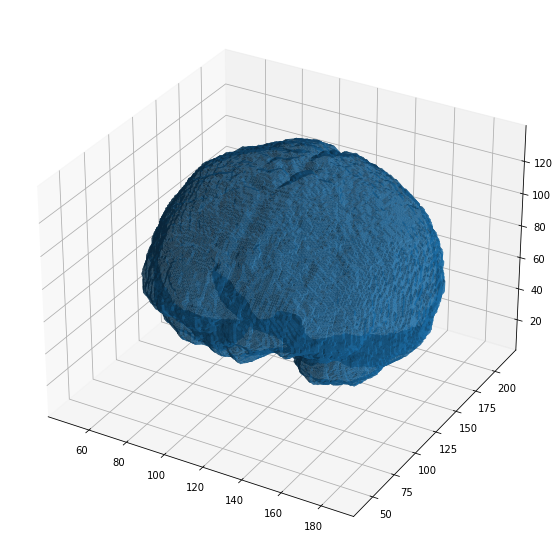

In [8]:
from skimage import measure

volume=images["FLAIR"]

verts,faces,_,_=measure.marching_cubes(volume,
                                       level=np.percentile(volume,70))

fig=plt.figure(figsize=(10,10))

ax=fig.add_subplot(111,projection='3d')

ax.plot_trisurf(
    verts[:,0],
    verts[:,1],
    faces,
    verts[:,2],
    linewidth=0.05,
    alpha=0.8
)

plt.show()

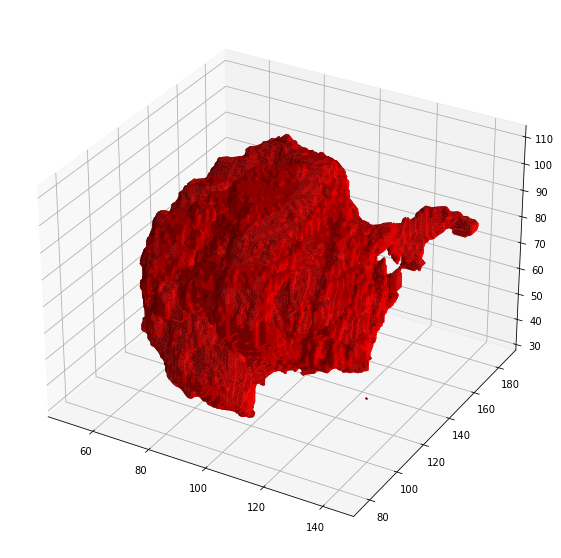

In [9]:
tumor=(images["SEG"]>0).astype(np.uint8)

verts,faces,_,_=measure.marching_cubes(
    tumor,
    level=0.5
)

fig=plt.figure(figsize=(10,10))

ax=fig.add_subplot(111,projection='3d')

ax.plot_trisurf(
    verts[:,0],
    verts[:,1],
    faces,
    verts[:,2],
    color='red'
)

plt.show()

In [10]:
!pip install timm

     |████████████████████████████████| 2.2 MB 12.4 MB/s 
     |████████████████████████████████| 67 kB 2.2 MB/s 
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... - \ error
  ERROR: Command errored out with exit status 1:
   command: /opt/conda/bin/python3.7 /opt/conda/lib/python3.7/site-packages/pip install --ignore-installed --no-user --prefix /tmp/pip-build-env-y661p0fb/normal --no-warn-script-location --no-binary :none: --only-binary :none: -i https://pypi.org/simple -- puccinialin
       cwd: None
  Complete output (4 lines):
  ERROR: Could not find a version that satisfies the requirement puccinialin
  ERROR: No matching distribution found for puccinialin
  You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.
  ----------------------------------------
     |████████████████████████████████| 66 kB 1.5 MB/s 
  Installing build depend

Total labeled subjects found: 368
Number of classes: 2 -> ['LGG', 'HGG']
  LGG: 76 samples (20.65%)
  HGG: 292 samples (79.35%)
Imbalance ratio (majority:minority): 3.84 : 1
Train subjects: 294 | Val subjects: 74
Train class counts (before oversampling): {'LGG': 61, 'HGG': 233}
Val class counts: {'LGG': 15, 'HGG': 59}
Train class counts (after oversampling): {'LGG': 233, 'HGG': 233}
Total train samples after oversampling: 466


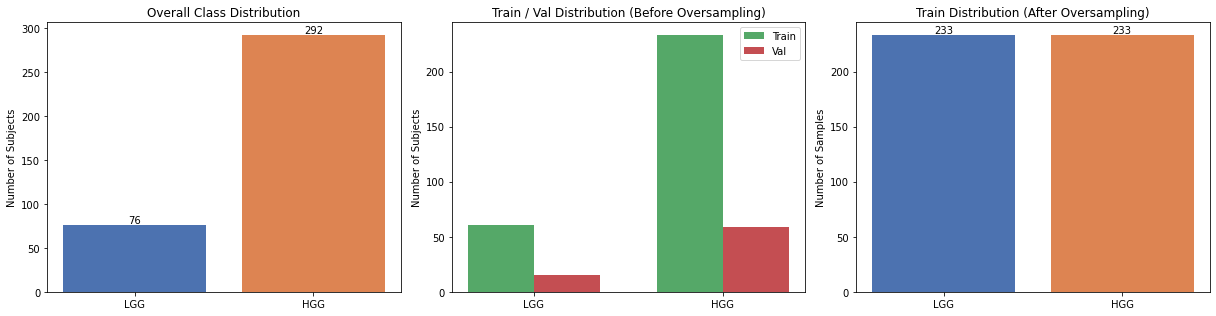

Downloading: "https://github.com/facebookresearch/dino/archive/main.zip" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall16_pretrain/dino_deitsmall16_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall16_pretrain.pth


  0%|          | 0.00/82.7M [00:00<?, ?B/s]

  0%|          | 0/233 [00:00<?, ?it/s]

Trainable parameters: 296,642
Total parameters: 21,962,306


  0%|          | 0/233 [00:00<?, ?it/s]

...

Epoch 4/5 | Train Loss 0.1231 Acc 0.9678 AUC 0.9893 | Val Loss 0.4984 Acc 0.7973 AUC 0.8350


Epoch 5/5 | Train Loss 0.0647 Acc 0.9850 AUC 0.9963 | Val Loss 0.4998 Acc 0.8108 AUC 0.8362


  0%|          | 0/37 [00:00<?, ?it/s]

Best validation AUC: 0.8362



===== Final Evaluation Metrics =====
Accuracy : 0.8108
Precision: 0.8814
Recall   : 0.8814
F1-score : 0.8814
AUC      : 0.8362

Classification Report:
              precision    recall  f1-score   support

         LGG       0.53      0.53      0.53        15
         HGG       0.88      0.88      0.88        59

    accuracy                           0.81        74
   macro avg       0.71      0.71      0.71        74
weighted avg       0.81      0.81      0.81        74



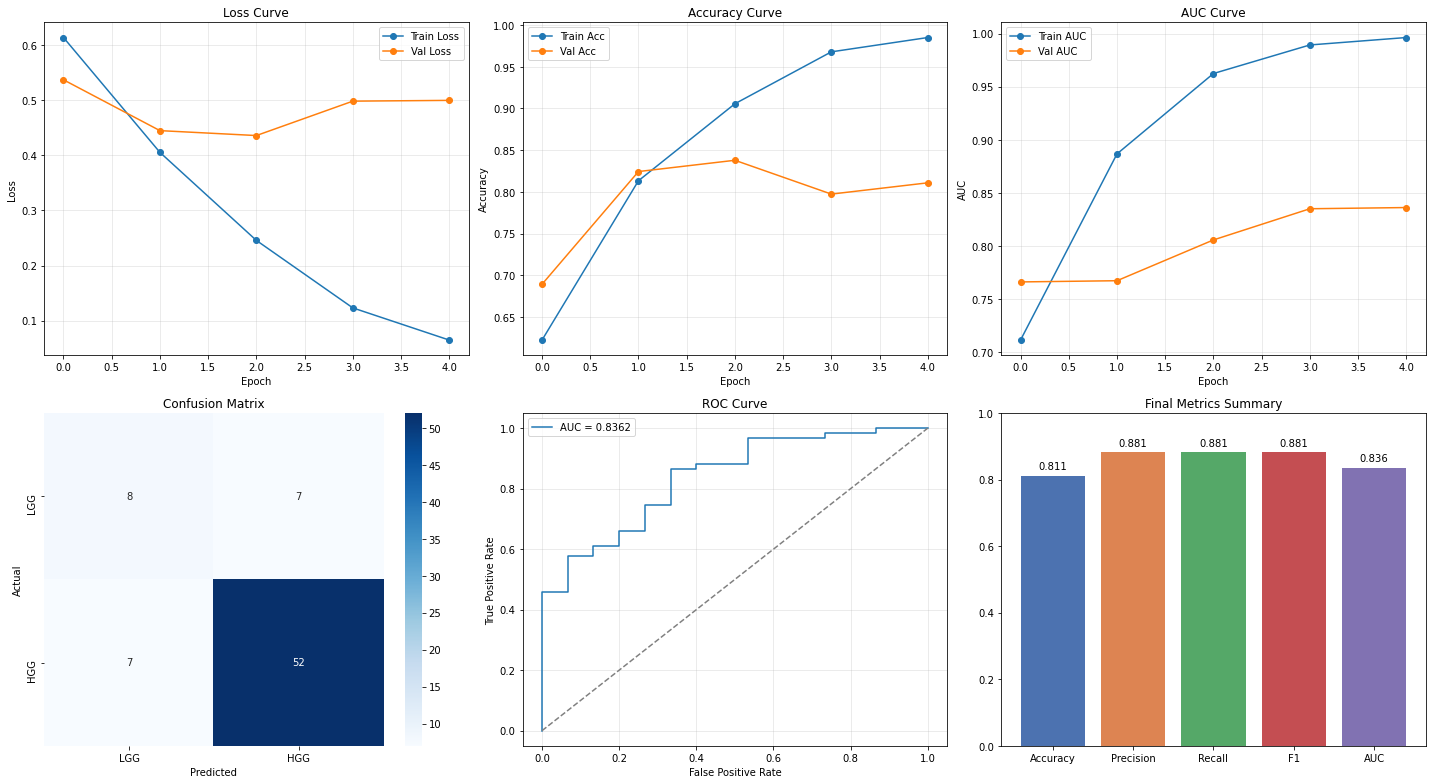

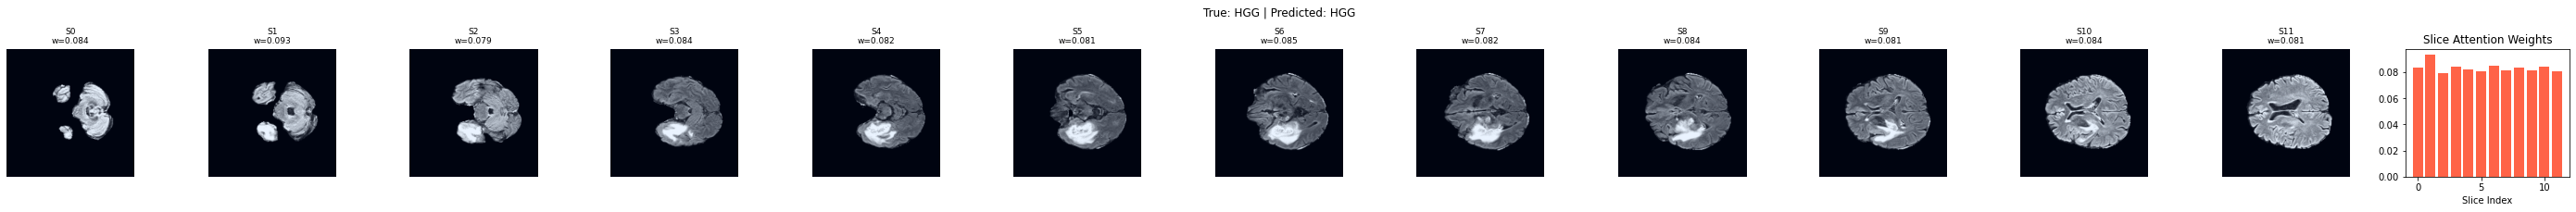


Training complete. Model saved to anymc3d_brats_best.pth


In [11]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
NAME_MAPPING_CSV = os.path.join(DATA_ROOT, "name_mapping.csv")

IMG_SIZE = 224
NUM_SLICES = 12
BATCH_SIZE = 2
EPOCHS = 5
LR = 1e-4
LORA_RANK = 8
LORA_ALPHA = 16
NUM_CLASSES = 2
EMBED_DIM = 384
BACKBONE_HUB_REPO = "facebookresearch/dino:main"
BACKBONE_HUB_NAME = "dino_vits16"

mapping_df = pd.read_csv(NAME_MAPPING_CSV)
mapping_df = mapping_df.dropna(subset=["BraTS_2020_subject_ID", "Grade"])
mapping_df["Grade"] = mapping_df["Grade"].str.strip()
label_map = {"LGG": 0, "HGG": 1}

all_patient_dirs = sorted(glob.glob(os.path.join(DATA_ROOT, "BraTS20_Training_*")))

samples = []
for pdir in all_patient_dirs:
    pid = os.path.basename(pdir)
    row = mapping_df[mapping_df["BraTS_2020_subject_ID"] == pid]
    if len(row) == 0:
        continue
    grade = row["Grade"].values[0]
    if grade not in label_map:
        continue
    flair_path = os.path.join(pdir, f"{pid}_flair.nii")
    seg_path = os.path.join(pdir, f"{pid}_seg.nii")
    if not os.path.exists(flair_path):
        flair_path = flair_path + ".gz"
    if not os.path.exists(seg_path):
        seg_path = seg_path + ".gz"
    if os.path.exists(flair_path) and os.path.exists(seg_path):
        samples.append((flair_path, seg_path, label_map[grade]))

print(f"Total labeled subjects found: {len(samples)}")

labels_all = [s[2] for s in samples]
NUM_CLASSES = len(set(labels_all))
inv_label_map = {v: k for k, v in label_map.items()}
class_names = [inv_label_map[i] for i in range(NUM_CLASSES)]

counts_all = np.bincount(labels_all, minlength=NUM_CLASSES)
print(f"Number of classes: {NUM_CLASSES} -> {class_names}")
for i, name in enumerate(class_names):
    pct = 100.0 * counts_all[i] / len(labels_all)
    print(f"  {name}: {counts_all[i]} samples ({pct:.2f}%)")
imbalance_ratio = counts_all.max() / counts_all.min()
print(f"Imbalance ratio (majority:minority): {imbalance_ratio:.2f} : 1")

train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED, stratify=labels_all
)
train_labels = [s[2] for s in train_samples]
val_labels = [s[2] for s in val_samples]
train_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
val_counts = np.bincount(val_labels, minlength=NUM_CLASSES)
print(f"Train subjects: {len(train_samples)} | Val subjects: {len(val_samples)}")
print(f"Train class counts (before oversampling): {dict(zip(class_names, train_counts.tolist()))}")
print(f"Val class counts: {dict(zip(class_names, val_counts.tolist()))}")

train_by_class = {c: [s for s in train_samples if s[2] == c] for c in range(NUM_CLASSES)}
max_count = max(len(v) for v in train_by_class.values())
balanced_train_samples = []
for c, items in train_by_class.items():
    if len(items) < max_count:
        rng = np.random.RandomState(SEED + c)
        extra_idx = rng.choice(len(items), size=max_count - len(items), replace=True)
        oversampled = items + [items[i] for i in extra_idx]
    else:
        oversampled = list(items)
    balanced_train_samples.extend(oversampled)
random.shuffle(balanced_train_samples)
train_samples = balanced_train_samples

balanced_labels = [s[2] for s in train_samples]
balanced_counts = np.bincount(balanced_labels, minlength=NUM_CLASSES)
print(f"Train class counts (after oversampling): {dict(zip(class_names, balanced_counts.tolist()))}")
print(f"Total train samples after oversampling: {len(train_samples)}")

fig_cls, axes_cls = plt.subplots(1, 3, figsize=(17, 4.5))
axes_cls[0].bar(class_names, counts_all, color=["#4C72B0", "#DD8452"])
axes_cls[0].set_title("Overall Class Distribution")
axes_cls[0].set_ylabel("Number of Subjects")
for i, v in enumerate(counts_all):
    axes_cls[0].text(i, v + 2, str(int(v)), ha="center")

width = 0.35
x = np.arange(NUM_CLASSES)
axes_cls[1].bar(x - width / 2, train_counts, width, label="Train", color="#55A868")
axes_cls[1].bar(x + width / 2, val_counts, width, label="Val", color="#C44E52")
axes_cls[1].set_xticks(x)
axes_cls[1].set_xticklabels(class_names)
axes_cls[1].set_title("Train / Val Distribution (Before Oversampling)")
axes_cls[1].set_ylabel("Number of Subjects")
axes_cls[1].legend()

axes_cls[2].bar(class_names, balanced_counts, color=["#4C72B0", "#DD8452"])
axes_cls[2].set_title("Train Distribution (After Oversampling)")
axes_cls[2].set_ylabel("Number of Samples")
for i, v in enumerate(balanced_counts):
    axes_cls[2].text(i, v + 2, str(int(v)), ha="center")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


def select_slice_indices(seg_volume, num_slices):
    tumor_slices = np.where(seg_volume.sum(axis=(0, 1)) > 0)[0]
    if len(tumor_slices) == 0:
        total = seg_volume.shape[2]
        idx = np.linspace(0, total - 1, num_slices).astype(int)
        return idx
    lo, hi = tumor_slices.min(), tumor_slices.max()
    if hi == lo:
        hi = min(hi + num_slices, seg_volume.shape[2] - 1)
    idx = np.linspace(lo, hi, num_slices).astype(int)
    idx = np.clip(idx, 0, seg_volume.shape[2] - 1)
    return idx


class BraTSVolumeDataset(Dataset):
    def __init__(self, samples, num_slices=NUM_SLICES, img_size=IMG_SIZE, augment=False):
        self.samples = samples
        self.num_slices = num_slices
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        flair_path, seg_path, label = self.samples[idx]
        flair = nib.load(flair_path).get_fdata().astype(np.float32)
        seg = nib.load(seg_path).get_fdata().astype(np.float32)

        indices = select_slice_indices(seg, self.num_slices)
        slices = []
        for s in indices:
            sl = flair[:, :, s]
            p1, p99 = np.percentile(sl, 1), np.percentile(sl, 99)
            sl = np.clip(sl, p1, p99)
            if p99 - p1 > 1e-6:
                sl = (sl - p1) / (p99 - p1)
            else:
                sl = np.zeros_like(sl)
            sl_t = torch.from_numpy(sl).unsqueeze(0).unsqueeze(0)
            sl_t = F.interpolate(sl_t, size=(self.img_size, self.img_size),
                                  mode="bilinear", align_corners=False)
            sl_t = sl_t.squeeze(0).repeat(3, 1, 1)
            if self.augment and random.random() < 0.5:
                sl_t = torch.flip(sl_t, dims=[2])
            slices.append(sl_t)

        volume_tensor = torch.stack(slices, dim=0)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        volume_tensor = (volume_tensor - mean) / std

        return volume_tensor, torch.tensor(label, dtype=torch.long)


class LoRALinear(nn.Module):
    def __init__(self, base_linear, rank=LORA_RANK, alpha=LORA_ALPHA):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False
        in_f = base_linear.in_features
        out_f = base_linear.out_features
        self.rank = rank
        self.scale = alpha / rank
        self.A = nn.Parameter(torch.randn(rank, in_f) * (1.0 / math.sqrt(in_f)))
        self.B = nn.Parameter(torch.zeros(out_f, rank))

    def forward(self, x):
        base_out = self.base(x)
        lora_out = (x @ self.A.t()) @ self.B.t()
        return base_out + self.scale * lora_out


def inject_lora(vit_model, rank=LORA_RANK, alpha=LORA_ALPHA):
    for param in vit_model.parameters():
        param.requires_grad = False
    for block in vit_model.blocks:
        block.attn.qkv = LoRALinear(block.attn.qkv, rank, alpha)
        block.attn.proj = LoRALinear(block.attn.proj, rank, alpha)
    return vit_model


def load_backbone():
    try:
        model = torch.hub.load(BACKBONE_HUB_REPO, BACKBONE_HUB_NAME, pretrained=True)
    except TypeError:
        model = torch.hub.load(BACKBONE_HUB_REPO, BACKBONE_HUB_NAME)
    return model


class AnyMC3D(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM,
                 num_classes=NUM_CLASSES, rank=LORA_RANK, alpha=LORA_ALPHA):
        super().__init__()
        self.backbone = load_backbone()
        self.backbone = inject_lora(self.backbone, rank, alpha)
        self.embed_dim = embed_dim
        self.task_query = nn.Parameter(torch.randn(embed_dim) * 0.02)
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(embed_dim // 2, num_classes)
        )

    def forward(self, x, return_attn=False):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)
        feats = self.backbone(x)
        feats = feats.view(B, S, -1)
        scores = (feats @ self.task_query) / math.sqrt(self.embed_dim)
        attn = torch.softmax(scores, dim=1)
        volume_embed = torch.einsum("bs,bsd->bd", attn, feats)
        logits = self.head(volume_embed)
        if return_attn:
            return logits, attn
        return logits


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


train_dataset = BraTSVolumeDataset(train_samples, augment=True)
val_dataset = BraTSVolumeDataset(val_samples, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

model = AnyMC3D().to(DEVICE)
print(f"Trainable parameters: {count_trainable_params(model):,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

class_counts = np.bincount(balanced_labels, minlength=NUM_CLASSES)
class_weights = torch.tensor(
    [len(balanced_labels) / (NUM_CLASSES * c) for c in class_counts], dtype=torch.float32
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for volumes, labels in tqdm(loader, leave=False):
            volumes = volumes.to(DEVICE)
            labels = labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(volumes)
            loss = criterion(logits, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * volumes.size(0)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float("nan")
    return avg_loss, acc, auc, all_labels, all_preds, all_probs


history = {"train_loss": [], "train_acc": [], "train_auc": [],
           "val_loss": [], "val_acc": [], "val_auc": []}

best_val_auc = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_auc, _, _, _ = run_epoch(model, train_loader, optimizer, criterion, train=True)
    val_loss, val_acc, val_auc, val_labels, val_preds, val_probs = run_epoch(
        model, val_loader, optimizer, criterion, train=False
    )
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["train_auc"].append(tr_auc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} AUC {tr_auc:.4f} | "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} AUC {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), "anymc3d_brats_best.pth")
print(f"Best validation AUC: {best_val_auc:.4f}")

final_loss, final_acc, final_auc, final_labels, final_preds, final_probs = run_epoch(
    model, val_loader, optimizer, criterion, train=False
)

precision = precision_score(final_labels, final_preds, zero_division=0)
recall = recall_score(final_labels, final_preds, zero_division=0)
f1 = f1_score(final_labels, final_preds, zero_division=0)
cm = confusion_matrix(final_labels, final_preds)

print("\n===== Final Evaluation Metrics =====")
print(f"Accuracy : {final_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {final_auc:.4f}")
print("\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=class_names, zero_division=0))

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

axes[0, 0].plot(history["train_loss"], marker="o", label="Train Loss")
axes[0, 0].plot(history["val_loss"], marker="o", label="Val Loss")
axes[0, 0].set_title("Loss Curve")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history["train_acc"], marker="o", label="Train Acc")
axes[0, 1].plot(history["val_acc"], marker="o", label="Val Acc")
axes[0, 1].set_title("Accuracy Curve")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(history["train_auc"], marker="o", label="Train AUC")
axes[0, 2].plot(history["val_auc"], marker="o", label="Val AUC")
axes[0, 2].set_title("AUC Curve")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("AUC")
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
axes[1, 0].set_title("Confusion Matrix")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(final_labels, final_probs)
axes[1, 1].plot(fpr, tpr, label=f"AUC = {final_auc:.4f}")
axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 1].set_title("ROC Curve")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

bars_x = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
bars_y = [final_acc, precision, recall, f1, final_auc]
axes[1, 2].bar(bars_x, bars_y, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title("Final Metrics Summary")
for i, v in enumerate(bars_y):
    axes[1, 2].text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("anymc3d_training_summary.png", dpi=150)
plt.show()

sample_volume, sample_label = val_dataset[0]
sample_volume = sample_volume.unsqueeze(0).to(DEVICE)
model.eval()
with torch.no_grad():
    logits, attn = model(sample_volume, return_attn=True)
    pred_class = torch.argmax(logits, dim=1).item()

attn_weights = attn[0].cpu().numpy()

fig, axes = plt.subplots(1, NUM_SLICES + 1, figsize=(3 * (NUM_SLICES + 1), 3.2))
volume_np = sample_volume[0].cpu().numpy()
for i in range(NUM_SLICES):
    img = volume_np[i].transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    axes[i].imshow(img)
    axes[i].set_title(f"S{i}\nw={attn_weights[i]:.3f}", fontsize=9)
    axes[i].axis("off")

axes[NUM_SLICES].bar(range(NUM_SLICES), attn_weights, color="tomato")
axes[NUM_SLICES].set_title("Slice Attention Weights")
axes[NUM_SLICES].set_xlabel("Slice Index")

plt.suptitle(f"True: {class_names[sample_label.item()]} | Predicted: {class_names[pred_class]}")
plt.tight_layout()
plt.savefig("anymc3d_slice_attention.png", dpi=150)
plt.show()

print("\nTraining complete. Model saved to anymc3d_brats_best.pth")